# PPA Optimisation Results & Algorithm Comparison

## Overview

This notebook presents **results from optimised PPA structures** for the Spanish (MIBEL) renewable energy market. It evaluates three global optimisation algorithms applied to the collared PPA parameter selection problem.

**Key Objectives**

1. **Algorithm Performance Comparison** - Evaluate Differential Evolution (DE), Dual Annealing (DA), and SHGO on PPA optimization
2. **Framework Robustness Assessment** - Test optimised parameters across different market periods (train/test split)
3. **Market Scenario Analysis** - Examine collar behaviour under varying market conditions (2022 stress event, post-crisis years)
4. **Convergence Characteristics** - Analyse computational efficiency and search patterns

## Important Context

- **This is a results notebook** - Contains actual optimised PPA parameters from objective function maximisation
- **Framework assessment, not prediction** - Results demonstrate algorithm behaviour on historical data and do not aim to prove predictive performance

## Structure

- **Part 1:** Full period optimisation results (2015-2025) for algorithm comparison
- **Part 2:** Train-test robustness check (cannot be interpreted as classic out-of-sample assessment)
- **Part 3:** Year-level scenario analysis (2022-2025 individual years)

---

## Setup

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json
import sys

# Add project root to path for src package imports
project_root = Path('..').resolve()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# Import analysis functions using package notation
from src.results_analysis import (
    load_optimisation_results,
    load_convergence_histories,
    load_search_logs,
    compare_train_test,
    summarise_full_period,
    analyse_convergence_speed,
    stress_test_by_years
)

# Plotting configuration
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('colorblind')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

# Algorithm names
ALGORITHMS = ['differential_evolution', 'dual_annealing', 'shgo']
ALGO_LABELS = {
    'differential_evolution': 'DE',
    'dual_annealing': 'DA',
    'shgo': 'SHGO'
}

## Part 1: Algorithm Comparison (Full Period)

**Goal:** Examine algorithm behaviour across the full historical dataset (2015-2025) to understand solution characteristics and computational requirements.

**Framework Assessment:**
- Solution characteristics: Fitness values, parameter structures
- Computational behaviour: Convergence patterns, evaluations, time
- Constraint handling: Feasibility across different algorithms

**Note:** Results serve as framework behaviour evaluation for historical market conditions, not as evidence of predictive performance.

### 1.1 Load Full Period Results

In [2]:
results = load_optimisation_results(
    algorithms=ALGORITHMS,
    periods=['full', 'train', 'test']
)

print("Loaded results:")
for key in results.keys():
    print(f"  {key}: {len(results[key])} rows")

Loaded results:
  differential_evolution_full: 1 rows
  differential_evolution_train: 1 rows
  differential_evolution_test: 1 rows
  dual_annealing_full: 1 rows
  dual_annealing_train: 1 rows
  dual_annealing_test: 1 rows
  shgo_full: 1 rows
  shgo_train: 1 rows
  shgo_test: 1 rows


In [3]:
# Load convergence histories
histories = load_convergence_histories(
    algorithms=ALGORITHMS,
    periods=['full', 'train']
)

print("\nLoaded convergence histories:")
for key, hist in histories.items():
    print(f"  {key}: {len(hist)} iterations")


Loaded convergence histories:
  differential_evolution_full: 12 iterations
  differential_evolution_train: 8 iterations
  dual_annealing_full: 5 iterations
  dual_annealing_train: 4 iterations
  shgo_full: 3884 iterations
  shgo_train: 4432 iterations


In [4]:
# Load search logs (for detailed analysis)
search_logs = load_search_logs(
    algorithms=ALGORITHMS,
    periods=['full', 'train']
)

print("\nLoaded search logs:")
for key, log in search_logs.items():
    print(f"  {key}: {len(log)} evaluations")


Loaded search logs:
  differential_evolution_full: 681 evaluations
  differential_evolution_train: 697 evaluations
  dual_annealing_full: 1078 evaluations
  dual_annealing_train: 909 evaluations
  shgo_full: 44336 evaluations
  shgo_train: 51319 evaluations


In [5]:
# Round all numeric values to 2 decimal places
columns_to_round = ['fitness', 'mean_revenue', 'cvar', 'var', 'penalty', 
                    'floor', 'strike', 'cap', 'spread', 'net_transfer_pct', 'time_sec']

for key in results.keys():
    for col in columns_to_round:
        if col in results[key].columns:
            results[key][col] = results[key][col].round(2)

# Round convergence histories (they contain dicts with iteration data)
for key in histories.keys():
    for entry in histories[key]:
        if isinstance(entry, dict):
            for field in ['fitness', 'floor', 'strike', 'cap', 'spread', 'penalty']:
                if field in entry:
                    entry[field] = round(entry[field], 2)
        elif isinstance(entry, (int, float)):
            # In case some histories are just numbers
            pass

# Round search log values
for key in search_logs.keys():
    for entry in search_logs[key]:
        for field in ['fitness', 'floor', 'strike', 'cap', 'mean_revenue', 'cvar', 'penalty']:
            if field in entry:
                entry[field] = round(entry[field], 2)

print("Rounded all numeric values to 2 decimal places")

Rounded all numeric values to 2 decimal places


### 1.2 Full Period Summary

In [6]:
# Create summary table
summary_full = summarise_full_period(results, ALGORITHMS)

# Format numeric columns for display
summary_display = summary_full.copy()
for col in ['fitness', 'mean_revenue', 'cvar']:
    if col in summary_display.columns:
        summary_display[col] = summary_display[col].apply(lambda x: f"{x:,.2f}")

print("Full Period Optimisation Results (2015-2025)")
print("=" * 100)
print(summary_display.to_string(index=False))
print()

# Identify best algorithm
best_algo = summary_full.loc[summary_full['fitness'].idxmax(), 'algorithm']
best_fitness = summary_full['fitness'].max()
print(f"Best Algorithm: {ALGO_LABELS[best_algo]} with fitness {best_fitness:,.0f} EUR")

Full Period Optimisation Results (2015-2025)
             algorithm    fitness mean_revenue       cvar  floor  strike    cap  spread  net_transfer_pct  is_feasible    time_sec  evaluations  fitness_rank
differential_evolution 564,206.55   600,506.96 237,502.88  58.79   72.61 227.35  168.56               4.9         True   19.809009          669             2
        dual_annealing 563,889.80   601,091.97 229,070.27  31.86   67.74 159.99  128.13               5.0         True   34.182307         1073             3
                  shgo 565,142.36   601,091.97 241,595.92  62.10   70.48 259.10  197.00               5.0         True 1429.016459        40452             1

Best Algorithm: SHGO with fitness 565,142 EUR


### 1.3 Solution Comparison

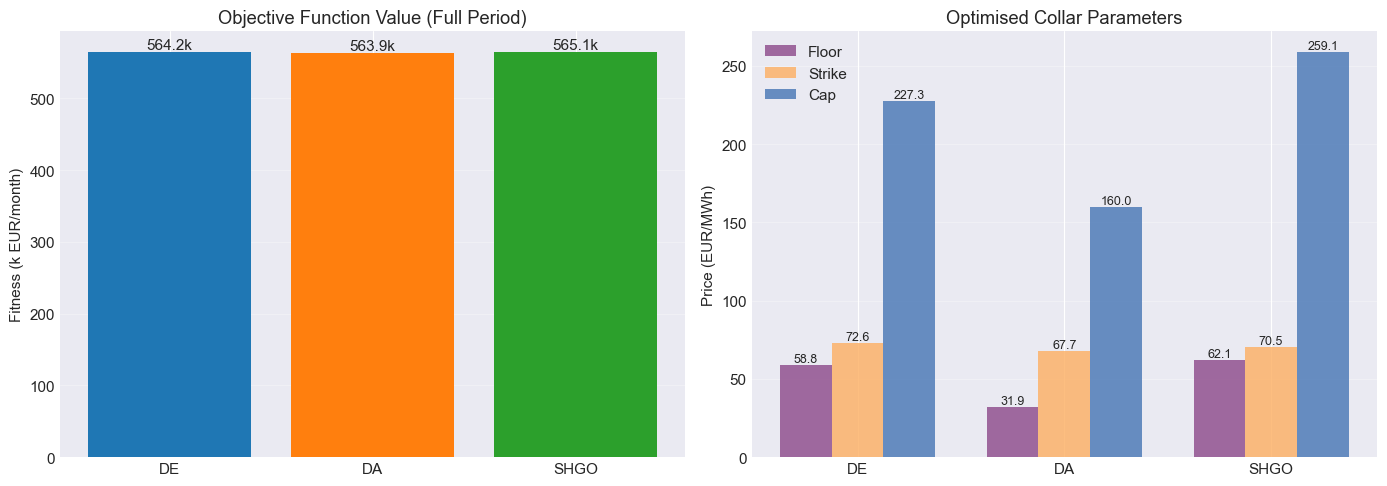

In [7]:
# Plot fitness comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Fitness bar chart
ax = axes[0]
summary_full['algo_label'] = summary_full['algorithm'].map(ALGO_LABELS)
bars = ax.bar(summary_full['algo_label'], summary_full['fitness'] / 1000, 
              color=['#1f77b4', '#ff7f0e', '#2ca02c'])
ax.set_ylabel('Fitness (k EUR/month)')
ax.set_title('Objective Function Value (Full Period)')
ax.grid(axis='y', alpha=0.3)

# Add values on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.1f}k', ha='center', va='bottom')

# Parameter comparison (collar structure)
ax = axes[1]
x = np.arange(len(summary_full))
width = 0.25

bars_floor = ax.bar(x - width, summary_full['floor'], width, label='Floor', color='#8B4789', alpha=0.8)
bars_strike = ax.bar(x, summary_full['strike'], width, label='Strike', color='#FDAE61', alpha=0.8)
bars_cap = ax.bar(x + width, summary_full['cap'], width, label='Cap', color='#4575B4', alpha=0.8)

ax.set_ylabel('Price (EUR/MWh)')
ax.set_title('Optimised Collar Parameters')
ax.set_xticks(x)
ax.set_xticklabels(summary_full['algo_label'])
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, (floor, strike, cap) in enumerate(zip(summary_full['floor'], summary_full['strike'], summary_full['cap'])):
    ax.text(i - width, floor, f'{floor:.1f}', ha='center', va='bottom', fontsize=9)
    ax.text(i, strike, f'{strike:.1f}', ha='center', va='bottom', fontsize=9)
    ax.text(i + width, cap, f'{cap:.1f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

### 1.4 Convergence Analysis

In [8]:
# Analyse convergence characteristics
conv_analysis = analyse_convergence_speed(histories, ALGORITHMS, period='full')

# Format numeric columns for display
conv_analysis_display = conv_analysis.copy()
for col in ['initial_fitness', 'final_fitness', 'best_fitness', 'improvement_from_start']:
    if col in conv_analysis_display.columns:
        conv_analysis_display[col] = conv_analysis_display[col].apply(lambda x: f"{x:,.2f}")

print("Convergence Analysis")
print("=" * 100)
print(conv_analysis_display.to_string(index=False))

Convergence Analysis
             algorithm  total_iterations initial_fitness final_fitness best_fitness  iterations_to_best improvement_from_start  improvement_pct
differential_evolution                12      563,979.54    564,206.55   564,206.55                   6                 227.01             0.04
        dual_annealing                 5      420,121.23    563,889.80   563,889.80                   5             143,768.57            34.22
                  shgo              3884      364,574.14    563,362.18   565,142.36                 131             200,568.22            55.01


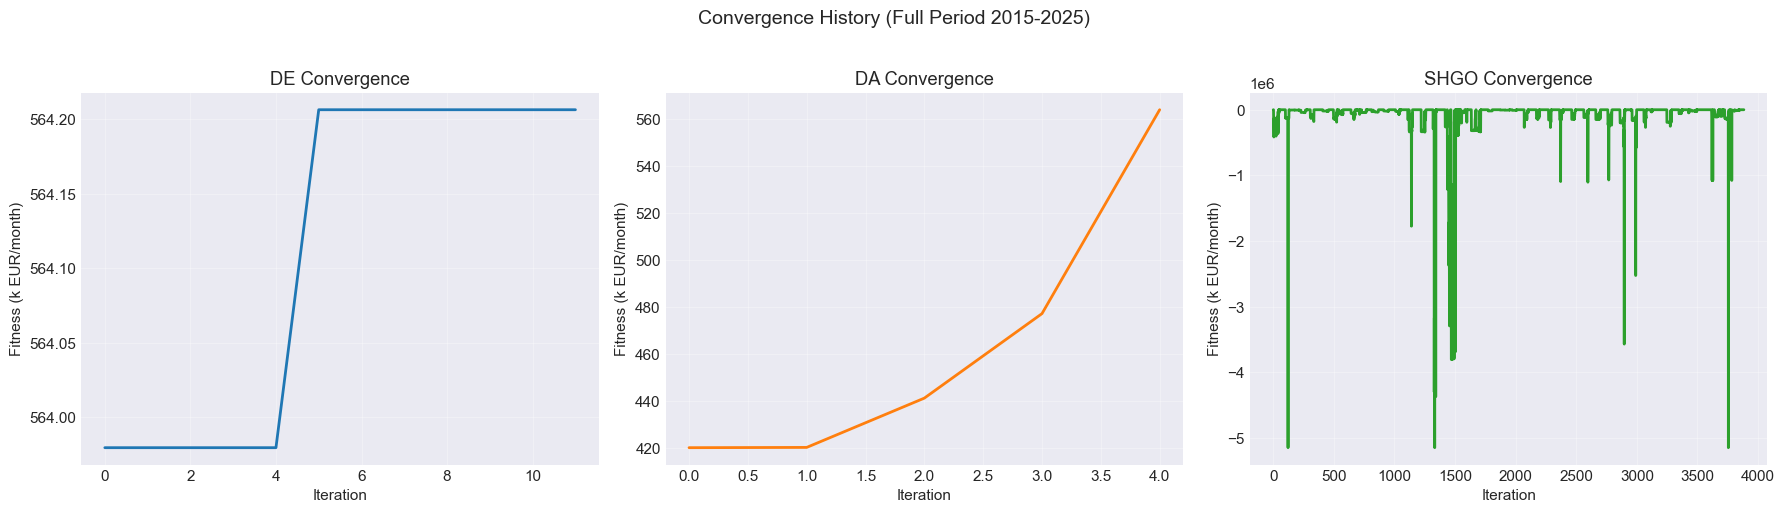

In [9]:
# Plot convergence curves - separate subplot per algorithm
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, algo in enumerate(ALGORITHMS):
    key = f'{algo}_full'
    ax = axes[i]
    
    if key in histories:
        history = histories[key]
        # Extract fitness values (history contains dicts with positive fitness values)
        if isinstance(history[0], dict):
            fitness_values = [entry['fitness']/1000 for entry in history]
        else:
            # Fallback for simple list of numbers
            fitness_values = [abs(f)/1000 for f in history]
        ax.plot(fitness_values, linewidth=2, color=['#1f77b4', '#ff7f0e', '#2ca02c'][i])
    
    ax.set_xlabel('Iteration')
    ax.set_ylabel('Fitness (k EUR/month)')
    ax.set_title(f'{ALGO_LABELS[algo]} Convergence')
    ax.grid(alpha=0.3)

fig.suptitle('Convergence History (Full Period 2015-2025)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 1.5 Computational Efficiency

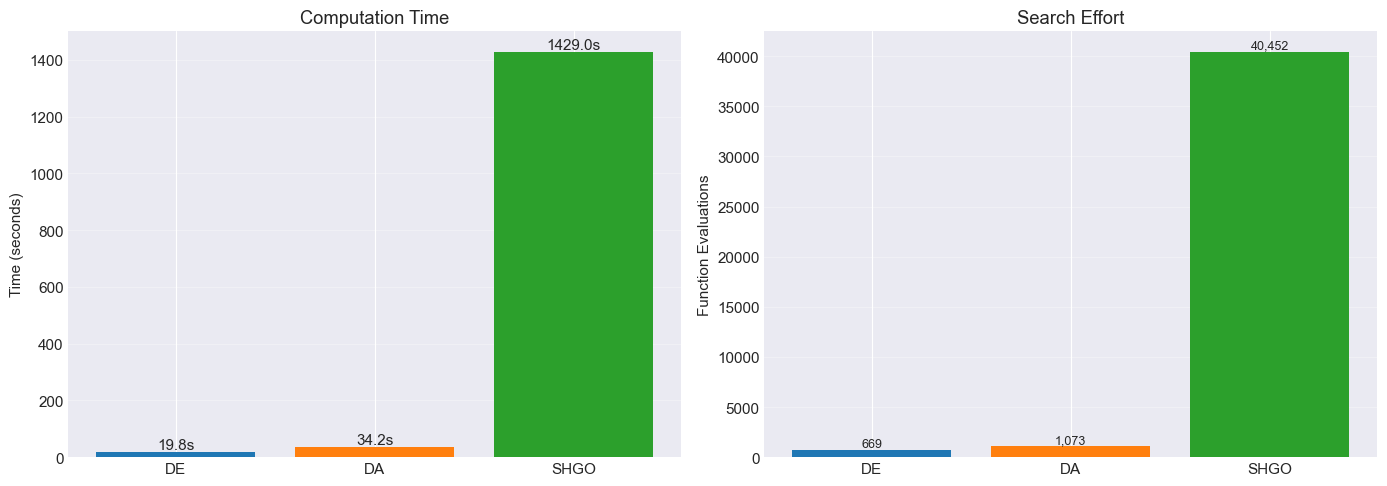

In [10]:
# Efficiency comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Computation time
ax = axes[0]
bars = ax.bar(summary_full['algo_label'], summary_full['time_sec'], 
              color=['#1f77b4', '#ff7f0e', '#2ca02c'])
ax.set_ylabel('Time (seconds)')
ax.set_title('Computation Time')
ax.grid(axis='y', alpha=0.3)

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.1f}s', ha='center', va='bottom')

# Number of evaluations
ax = axes[1]
bars = ax.bar(summary_full['algo_label'], summary_full['evaluations'], 
              color=['#1f77b4', '#ff7f0e', '#2ca02c'])
ax.set_ylabel('Function Evaluations')
ax.set_title('Search Effort')
ax.grid(axis='y', alpha=0.3)

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height):,}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

### 1.6 Search Space Exploration

Search Space Exploration Pattern
Red dots = Infeasible solutions (violate constraints)
Colored dots = Feasible solutions (color indicates fitness value)



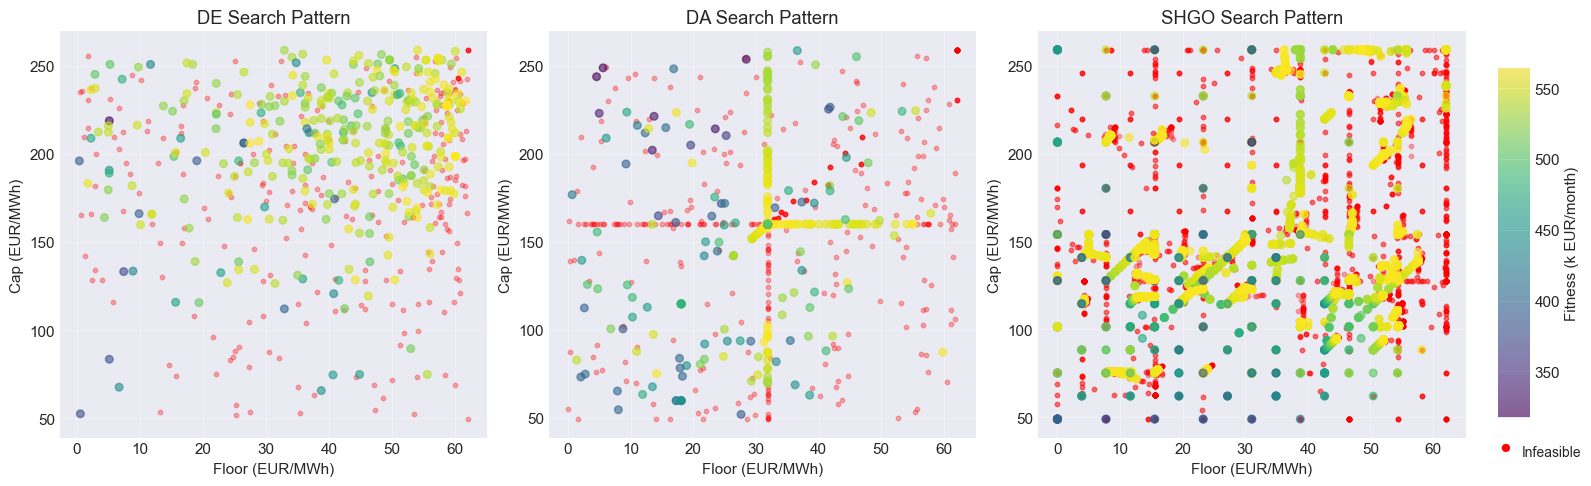

In [11]:
# Analyze search patterns from search logs
print("Search Space Exploration Pattern")
print("=" * 100)
print("Red dots = Infeasible solutions (violate constraints)")
print("Colored dots = Feasible solutions (color indicates fitness value)")
print()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Track scatter for colorbar (only add once)
scatter_obj = None

for i, algo in enumerate(ALGORITHMS):
    key = f'{algo}_full'
    if key not in search_logs:
        continue
    
    log = search_logs[key]
    
    # Extract data
    floors = [e['floor'] for e in log]
    caps = [e['cap'] for e in log]
    fitness = [e['fitness'] for e in log]
    feasible = [e['is_feasible'] for e in log]
    
    ax = axes[i]
    
    # Plot feasible vs infeasible
    feasible_idx = [j for j, f in enumerate(feasible) if f]
    infeasible_idx = [j for j, f in enumerate(feasible) if not f]
    
    if infeasible_idx:
        ax.scatter([floors[j] for j in infeasible_idx], 
                   [caps[j] for j in infeasible_idx],
                   c='red', alpha=0.3, s=10)
    
    if feasible_idx:
        scatter = ax.scatter([floors[j] for j in feasible_idx], 
                            [caps[j] for j in feasible_idx],
                            c=[fitness[j]/1000 for j in feasible_idx], 
                            cmap='viridis', alpha=0.6, s=30)
        if scatter_obj is None:
            scatter_obj = scatter
    
    ax.set_xlabel('Floor (EUR/MWh)')
    ax.set_ylabel('Cap (EUR/MWh)')
    ax.set_title(f'{ALGO_LABELS[algo]} Search Pattern')
    ax.grid(alpha=0.3)

plt.tight_layout()

# Add single colorbar on the right
if scatter_obj is not None:
    fig.subplots_adjust(right=0.92)
    cbar_ax = fig.add_axes([0.94, 0.15, 0.02, 0.7])
    cbar = fig.colorbar(scatter_obj, cax=cbar_ax, label='Fitness (k EUR/month)', 
                        format=lambda x, _: f'{x:.0f}')
    
    # Add infeasible legend below colorbar
    fig.text(0.945, 0.08, '●', color='red', fontsize=14, ha='center')
    fig.text(0.955, 0.08, 'Infeasible', fontsize=10, ha='left', va='center')

plt.show()

### 1.7 Fitness Range Exploration

In [12]:
# Analyse fitness range explored by each algorithm
exploration_data = []

for algo in ALGORITHMS:
    key = f'{algo}_full'
    if key not in search_logs:
        continue
    
    log = search_logs[key]
    
    # Extract fitness values and feasibility
    fitness_vals = [e['fitness'] for e in log]
    feasible_vals = [e['fitness'] for e in log if e['is_feasible']]
    infeasible_vals = [e['fitness'] for e in log if not e['is_feasible']]
    
    exploration_data.append({
        'algorithm': ALGO_LABELS[algo],
        'total_evals': len(log),
        'feasible_evals': len(feasible_vals),
        'infeasible_evals': len(infeasible_vals),
        'infeasible_pct': round((len(infeasible_vals) / len(log)) * 100, 1),
        'fitness_min': round(min(fitness_vals), 2),
        'fitness_max': round(max(fitness_vals), 2),
        'fitness_range': round((max(fitness_vals) - min(fitness_vals)), 2),
        'feasible_min': round(min(feasible_vals), 2) if feasible_vals else None,
        'feasible_max': round(max(feasible_vals), 2) if feasible_vals else None
    })

exploration_df = pd.DataFrame(exploration_data)

# Format numeric columns for display
exploration_display = exploration_df.copy()
for col in ['fitness_min', 'fitness_max', 'fitness_range', 'feasible_min', 'feasible_max']:
    if col in exploration_display.columns:
        exploration_display[col] = exploration_display[col].apply(lambda x: f"{x:,.2f}" if pd.notna(x) else x)

print("\n=== Fitness Range Exploration ===")
print(exploration_display.to_string(index=False))

# Calculate how deep into infeasible regions each algorithm went
print("\n=== Key Insights ===")
for _, row in exploration_df.iterrows():
    if row['infeasible_evals'] > 0:
        print(f"{row['algorithm']}: Explored {row['infeasible_pct']:.1f}% infeasible solutions")
        print(f"  → Worst fitness: {row['fitness_min']:,.2f} EUR/month")
        print(f"  → Range: {row['fitness_range']:,.2f} EUR/month")


=== Fitness Range Exploration ===
algorithm  total_evals  feasible_evals  infeasible_evals  infeasible_pct       fitness_min fitness_max    fitness_range feasible_min feasible_max
       DE          681             396               285            41.9 -3,954,191,138.63  564,571.22 3,954,755,709.85   317,441.40   564,571.22
       DA         1078             563               515            47.8 -4,290,020,941.08  563,889.80 4,290,584,830.88   312,629.05   563,889.80
     SHGO        44336           30031             14305            32.3 -5,152,600,000.00  565,142.36 5,153,165,142.36   296,425.75   565,142.36

=== Key Insights ===
DE: Explored 41.9% infeasible solutions
  → Worst fitness: -3,954,191,138.63 EUR/month
  → Range: 3,954,755,709.85 EUR/month
DA: Explored 47.8% infeasible solutions
  → Worst fitness: -4,290,020,941.08 EUR/month
  → Range: 4,290,584,830.88 EUR/month
SHGO: Explored 32.3% infeasible solutions
  → Worst fitness: -5,152,600,000.00 EUR/month
  → Range: 5,153,165

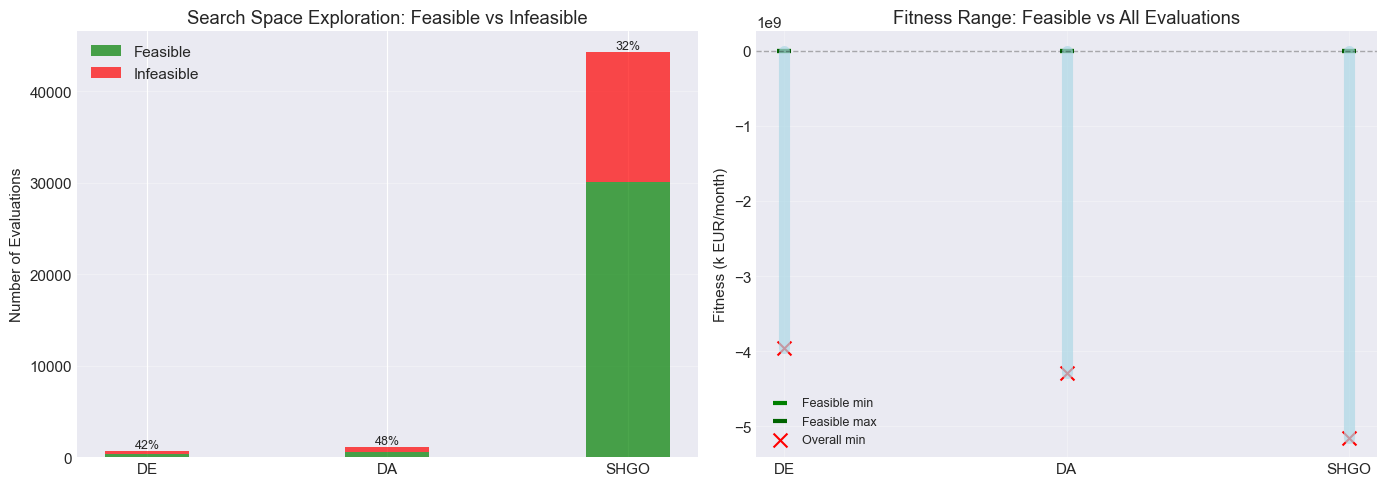

In [13]:
# Visualise fitness range exploration
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Feasible vs Infeasible evaluations
ax = axes[0]
x = np.arange(len(exploration_df))
width = 0.35

ax.bar(x, exploration_df['feasible_evals'], width, label='Feasible', 
       color='green', alpha=0.7)
ax.bar(x, exploration_df['infeasible_evals'], width, bottom=exploration_df['feasible_evals'],
       label='Infeasible', color='red', alpha=0.7)

ax.set_ylabel('Number of Evaluations')
ax.set_title('Search Space Exploration: Feasible vs Infeasible')
ax.set_xticks(x)
ax.set_xticklabels(exploration_df['algorithm'])
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Add percentage labels
for i, (feas, infeas, total) in enumerate(zip(exploration_df['feasible_evals'], 
                                                exploration_df['infeasible_evals'],
                                                exploration_df['total_evals'])):
    pct = (infeas / total) * 100
    ax.text(i, total, f'{pct:.0f}%', ha='center', va='bottom', fontsize=9)

# Right: Fitness range (min to max)
ax = axes[1]
for i, row in exploration_df.iterrows():
    ax.plot([i, i], [row['fitness_min'], row['fitness_max']], 
            linewidth=8, color='lightblue', alpha=0.7)
    ax.scatter(i, row['feasible_min'], s=100, color='green', marker='_', 
               linewidths=3, label='Feasible min' if i == 0 else '')
    ax.scatter(i, row['feasible_max'], s=100, color='darkgreen', marker='_', 
               linewidths=3, label='Feasible max' if i == 0 else '')
    ax.scatter(i, row['fitness_min'], s=100, color='red', marker='x',
               label='Overall min' if i == 0 else '')

ax.set_ylabel('Fitness (k EUR/month)')
ax.set_title('Fitness Range: Feasible vs All Evaluations')
ax.set_xticks(range(len(exploration_df)))
ax.set_xticklabels(exploration_df['algorithm'])
ax.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.3)
ax.legend(loc='lower left', fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

---

## Part 2: Framework Robustness Check

**Goal:** Examine how optimised parameters behave when applied to different historical market periods.

**Setup:**
- Train period (2015-2021): 84 months, includes COVID recovery
- Test period (2023-2025): 36 months, post-crisis normalisation
- Note: 2022 excluded from test period (treated separately due to stress event following the Russian invasion of Ukraine)

**Framework Assessment:**
1. How do fitness values vary across different market periods?
2. Do constraint structures remain satisfied in different conditions?
3. How sensitive are solutions to market regime changes?

**Note:** This is not a train/test validation in the predictive sense. Results illustrate framework behaviour across historical market regimes rather than forecasting capability.

### 2.1 Train vs Test Comparison

In [14]:
# Compare train and test performance
comparison = compare_train_test(results, ALGORITHMS)

# Format numeric columns for display
comparison_display = comparison.copy()
for col in ['fitness', 'mean_revenue', 'cvar']:
    if col in comparison_display.columns:
        comparison_display[col] = comparison_display[col].apply(lambda x: f"{x:,.2f}")

print("Train vs Test Performance")
print("=" * 100)
print(comparison_display[['algorithm', 'period', 'fitness', 'mean_revenue', 'cvar', 
                  'penalty', 'is_feasible', 'net_transfer_pct']].to_string(index=False))

Train vs Test Performance
             algorithm period    fitness mean_revenue       cvar  penalty  is_feasible  net_transfer_pct
differential_evolution  train 497,198.98   529,207.00 209,126.76      0.0         True              4.97
differential_evolution   test 463,495.11   489,912.78 225,736.05      0.0         True              4.78
        dual_annealing  train 498,115.67   529,347.89 217,024.06      0.0         True              5.00
        dual_annealing   test 462,998.12   490,440.14 211,718.84      0.0         True              4.90
                  shgo  train 498,294.07   529,348.20 218,806.89      0.0         True              5.00
                  shgo   test 464,382.13   490,928.78 225,462.24      0.0         True              5.00


In [15]:
# Calculate and display degradation metrics
test_results = comparison[comparison['period'] == 'test'].copy()
test_results['algo_label'] = test_results['algorithm'].map(ALGO_LABELS)

# Format for display
test_results_display = test_results[['algo_label', 'fitness_change', 'fitness_change_pct']].copy()
test_results_display['fitness_change'] = test_results_display['fitness_change'].apply(lambda x: f"{x:,.2f}")
test_results_display['fitness_change_pct'] = test_results_display['fitness_change_pct'].apply(lambda x: f"{x:.2f}")

print("\nOut-of-Sample Performance Change")
print("=" * 100)
print(test_results_display.to_string(index=False))
print()

# Interpretation
avg_change = test_results['fitness_change_pct'].mean()
if avg_change > 0:
    print(f"✓ Average fitness INCREASED by {avg_change:.1f}% on test data")
    print("  (Higher test prices led to better outcomes)")
else:
    print(f"✗ Average fitness DECREASED by {abs(avg_change):.1f}% on test data")
    print("  (May indicate overfitting or regime change)")


Out-of-Sample Performance Change
algo_label fitness_change fitness_change_pct
        DE     -33,703.87              -6.78
        DA     -35,117.55              -7.05
      SHGO     -33,911.94              -6.81

✗ Average fitness DECREASED by 6.9% on test data
  (May indicate overfitting or regime change)


### 2.2 Fitness Component Breakdown

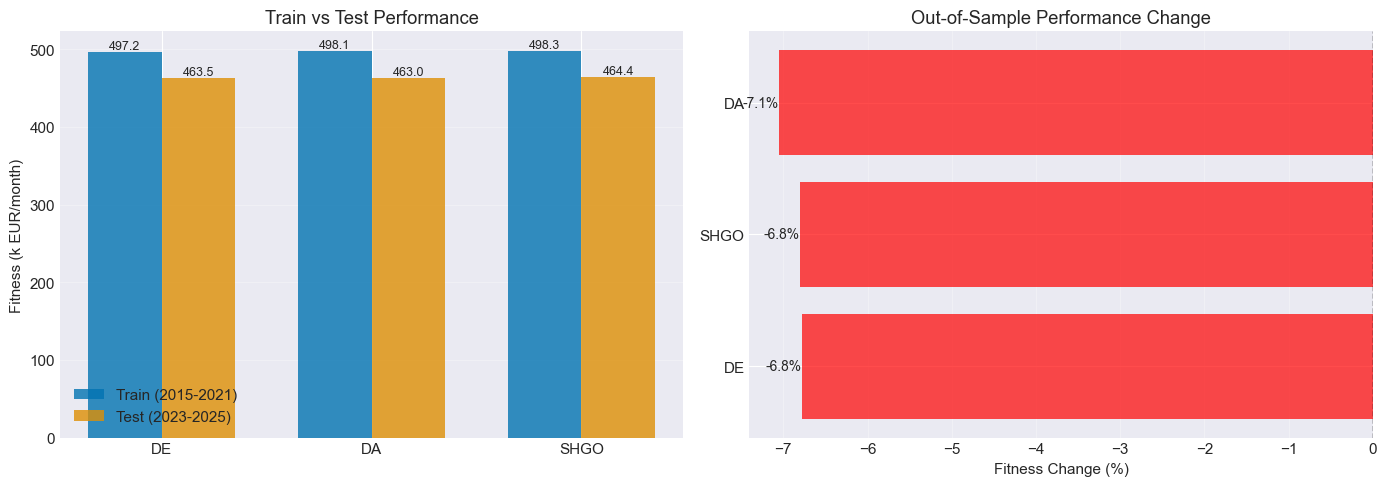

In [16]:
# Plot train vs test fitness
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Grouped bar chart
ax = axes[0]
x = np.arange(len(ALGORITHMS))
width = 0.35

train_data = comparison[comparison['period'] == 'train']
test_data = comparison[comparison['period'] == 'test']

ax.bar(x - width/2, train_data['fitness']/1000, width, label='Train (2015-2021)', alpha=0.8)
ax.bar(x + width/2, test_data['fitness']/1000, width, label='Test (2023-2025)', alpha=0.8)

ax.set_ylabel('Fitness (k EUR/month)')
ax.set_title('Train vs Test Performance')
ax.set_xticks(x)
ax.set_xticklabels([ALGO_LABELS[a] for a in ALGORITHMS])
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Add value labels
for i, algo in enumerate(ALGORITHMS):
    train_val = train_data[train_data['algorithm'] == algo]['fitness'].values[0] / 1000
    test_val = test_data[test_data['algorithm'] == algo]['fitness'].values[0] / 1000
    ax.text(i - width/2, train_val, f'{train_val:.1f}', 
            ha='center', va='bottom', fontsize=9)
    ax.text(i + width/2, test_val, f'{test_val:.1f}', 
            ha='center', va='bottom', fontsize=9)

# Percentage change
ax = axes[1]
test_data_sorted = test_data.sort_values('fitness_change_pct', ascending=False)
colors = ['green' if x > 0 else 'red' for x in test_data_sorted['fitness_change_pct']]
bars = ax.barh(test_data_sorted['algorithm'].map(ALGO_LABELS), 
               test_data_sorted['fitness_change_pct'],
               color=colors, alpha=0.7)

ax.set_xlabel('Fitness Change (%)')
ax.set_title('Out-of-Sample Performance Change')
ax.axvline(x=0, color='black', linestyle='--', linewidth=1)
ax.grid(axis='x', alpha=0.3)

# Add value labels
for i, bar in enumerate(bars):
    width = bar.get_width()
    ax.text(width, bar.get_y() + bar.get_height()/2.,
            f'{width:+.1f}%', ha='left' if width > 0 else 'right', 
            va='center', fontsize=10)

plt.tight_layout()
plt.show()

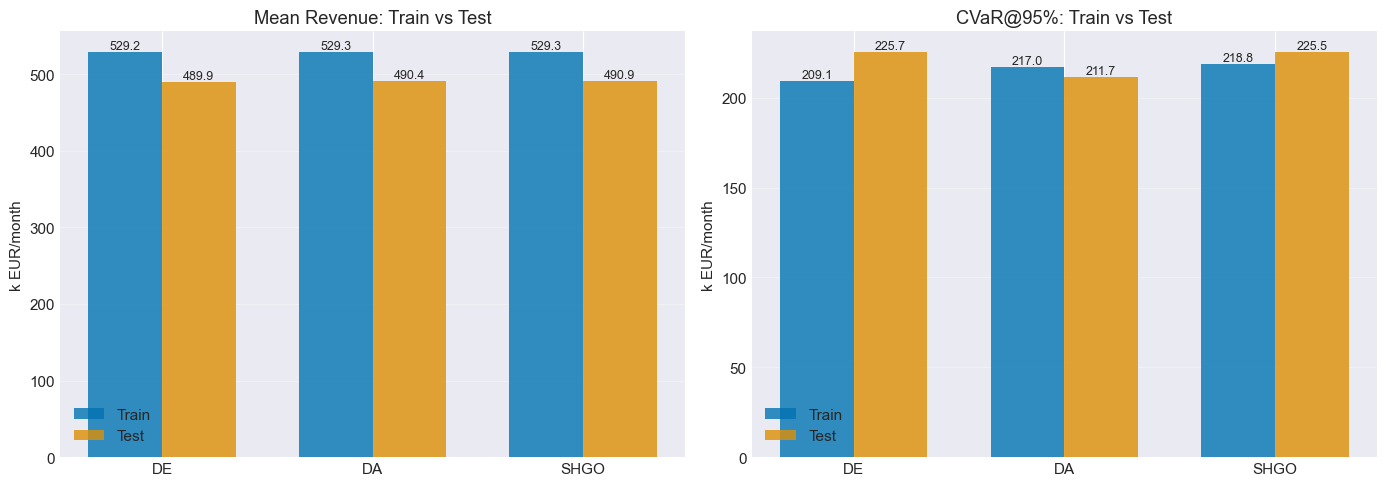

In [17]:
# Component analysis: Mean Revenue vs CVaR
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, component in enumerate(['mean_revenue', 'cvar']):
    ax = axes[i]
    x = np.arange(len(ALGORITHMS))
    width = 0.35
    
    train_vals = train_data[component].values / 1000
    test_vals = test_data[component].values / 1000
    
    ax.bar(x - width/2, train_vals, width, label='Train', alpha=0.8)
    ax.bar(x + width/2, test_vals, width, label='Test', alpha=0.8)
    
    ax.set_ylabel('k EUR/month')
    title = 'Mean Revenue' if component == 'mean_revenue' else 'CVaR@95%'
    ax.set_title(f'{title}: Train vs Test')
    ax.set_xticks(x)
    ax.set_xticklabels([ALGO_LABELS[a] for a in ALGORITHMS])
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    
    # Add value labels above bars
    for j in range(len(ALGORITHMS)):
        ax.text(j - width/2, train_vals[j], f'{train_vals[j]:.1f}', 
                ha='center', va='bottom', fontsize=9)
        ax.text(j + width/2, test_vals[j], f'{test_vals[j]:.1f}', 
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

### 2.3 Constraint Satisfaction

In [18]:
# Check constraint violations
print("Constraint Satisfaction Analysis")
print("=" * 100)

for _, row in comparison.iterrows():
    algo_label = ALGO_LABELS[row['algorithm']]
    period = row['period'].capitalize()
    feasible = '✓' if row['is_feasible'] else '✗'
    penalty = row['penalty']
    transfer = row['net_transfer_pct']
    
    print(f"{algo_label:6} {period:5}: {feasible} Feasible | "
          f"Penalty: {penalty:>8.0f} EUR | "
          f"Net Transfer: {transfer:>6.2f}% (limit: 5.00%)")

print()
all_feasible = comparison['is_feasible'].all()
if all_feasible:
    print("✓ All solutions remain feasible on both train and test data")
else:
    print("✗ Some solutions violated constraints")

Constraint Satisfaction Analysis
DE     Train: ✓ Feasible | Penalty:        0 EUR | Net Transfer:   4.97% (limit: 5.00%)
DE     Test : ✓ Feasible | Penalty:        0 EUR | Net Transfer:   4.78% (limit: 5.00%)
DA     Train: ✓ Feasible | Penalty:        0 EUR | Net Transfer:   5.00% (limit: 5.00%)
DA     Test : ✓ Feasible | Penalty:        0 EUR | Net Transfer:   4.90% (limit: 5.00%)
SHGO   Train: ✓ Feasible | Penalty:        0 EUR | Net Transfer:   5.00% (limit: 5.00%)
SHGO   Test : ✓ Feasible | Penalty:        0 EUR | Net Transfer:   5.00% (limit: 5.00%)

✓ All solutions remain feasible on both train and test data


### 2.4 Convergence Comparison: Train Period

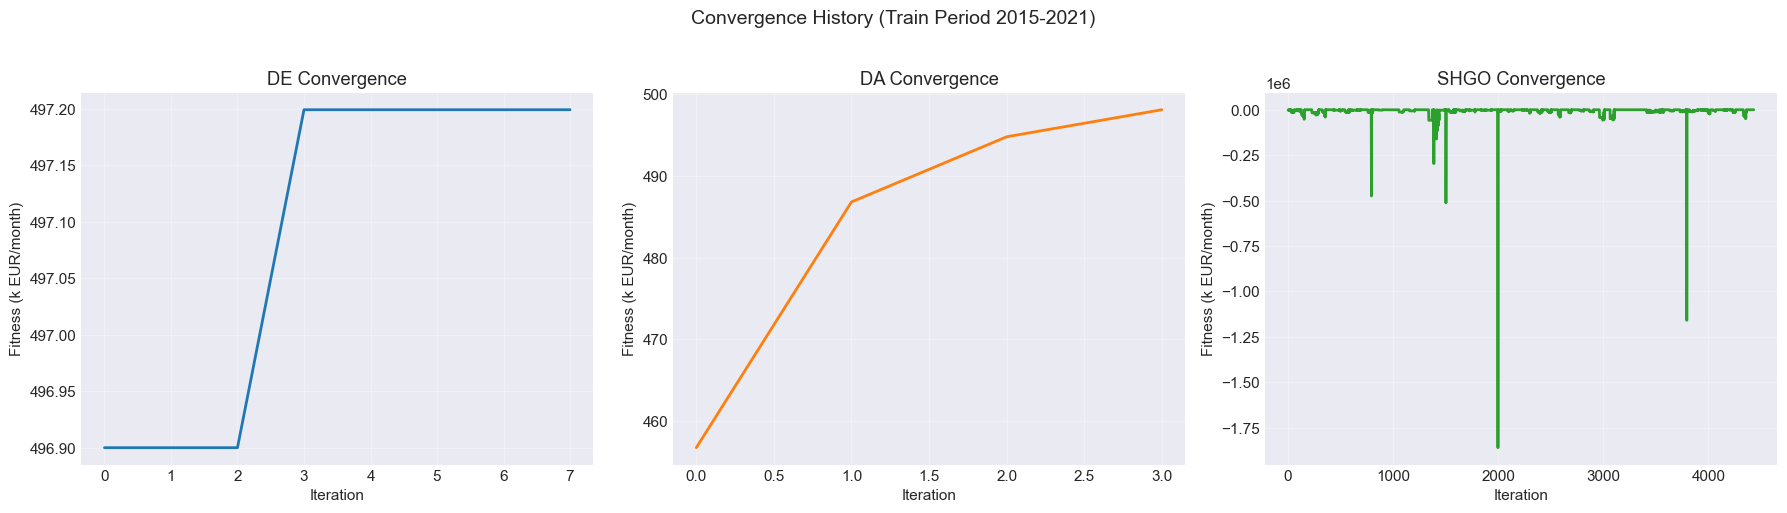

In [19]:
# Plot train period convergence - separate subplot per algorithm
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, algo in enumerate(ALGORITHMS):
    key = f'{algo}_train'
    ax = axes[i]
    
    if key in histories:
        history = histories[key]
        # Extract fitness values (history contains dicts with positive fitness values)
        if isinstance(history[0], dict):
            fitness_values = [entry['fitness']/1000 for entry in history]
        else:
            # Fallback for simple list of numbers
            fitness_values = [abs(f)/1000 for f in history]
        ax.plot(fitness_values, linewidth=2, color=['#1f77b4', '#ff7f0e', '#2ca02c'][i])
    
    ax.set_xlabel('Iteration')
    ax.set_ylabel('Fitness (k EUR/month)')
    ax.set_title(f'{ALGO_LABELS[algo]} Convergence')
    ax.grid(alpha=0.3)

fig.suptitle('Convergence History (Train Period 2015-2021)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 2.5 Parameter Spread Across Optimisation Periods

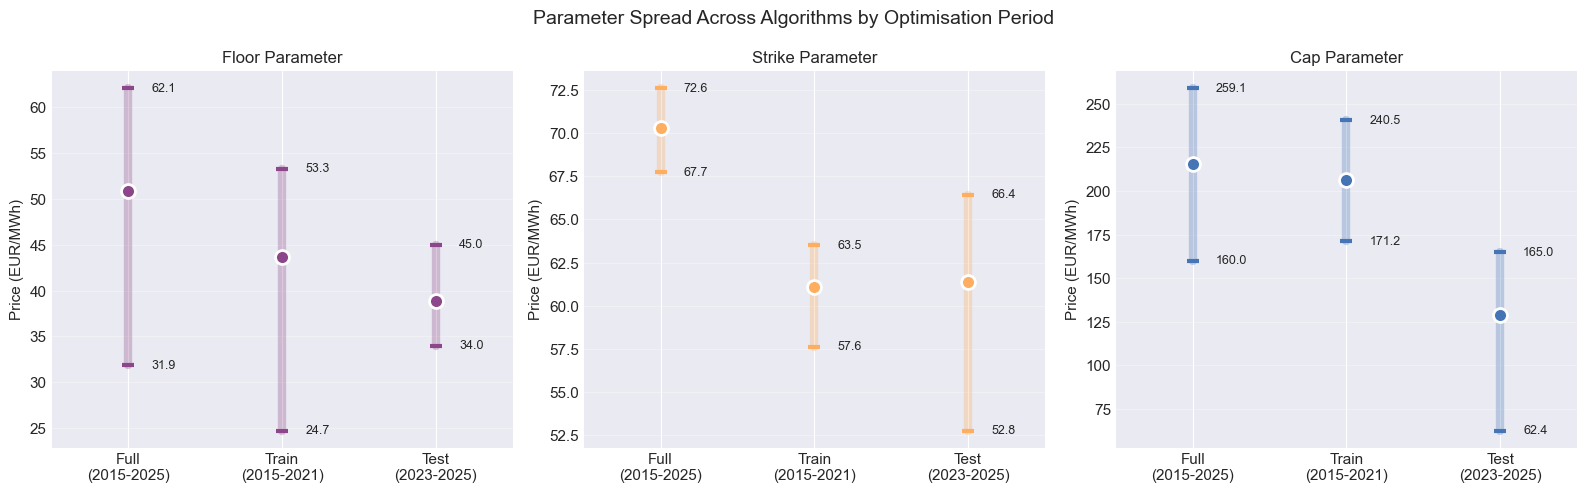


Parameter Spread Summary:

FLOOR:
  Full (2015-2025)    : Range [ 31.86,  62.10]  |  Mean:  50.92  |  Spread: 30.24 EUR/MWh
  Train (2015-2021)   : Range [ 24.71,  53.31]  |  Mean:  43.66  |  Spread: 28.60 EUR/MWh
  Test (2023-2025)    : Range [ 33.99,  45.00]  |  Mean:  38.87  |  Spread: 11.01 EUR/MWh

STRIKE:
  Full (2015-2025)    : Range [ 67.74,  72.61]  |  Mean:  70.28  |  Spread:  4.87 EUR/MWh
  Train (2015-2021)   : Range [ 57.62,  63.52]  |  Mean:  61.11  |  Spread:  5.90 EUR/MWh
  Test (2023-2025)    : Range [ 52.76,  66.42]  |  Mean:  61.38  |  Spread: 13.66 EUR/MWh

CAP:
  Full (2015-2025)    : Range [159.99, 259.10]  |  Mean: 215.48  |  Spread: 99.11 EUR/MWh
  Train (2015-2021)   : Range [171.22, 240.49]  |  Mean: 206.20  |  Spread: 69.27 EUR/MWh
  Test (2023-2025)    : Range [ 62.40, 165.01]  |  Mean: 128.70  |  Spread: 102.61 EUR/MWh


In [20]:
# Extract parameter ranges for each period across algorithms
periods = ['full', 'train', 'test']
period_labels = ['Full\n(2015-2025)', 'Train\n(2015-2021)', 'Test\n(2023-2025)']
parameters = ['floor', 'strike', 'cap']

# Collect parameter values for each period
param_ranges = {param: {'min': [], 'max': [], 'mean': []} for param in parameters}

for period in periods:
    for param in parameters:
        values = []
        for algo in ALGORITHMS:
            key = f'{algo}_{period}'
            if key in results:
                values.append(results[key].iloc[0][param])
        
        if values:
            param_ranges[param]['min'].append(min(values))
            param_ranges[param]['max'].append(max(values))
            param_ranges[param]['mean'].append(np.mean(values))

# Create range plot
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors = ['#8B4789', '#FDAE61', '#4575B4']

for idx, param in enumerate(parameters):
    ax = axes[idx]
    x = np.arange(len(periods))
    
    mins = param_ranges[param]['min']
    maxs = param_ranges[param]['max']
    means = param_ranges[param]['mean']
    
    # Plot range lines
    for i in range(len(periods)):
        ax.plot([i, i], [mins[i], maxs[i]], color=colors[idx], 
                linewidth=6, alpha=0.3, solid_capstyle='round')
        
        # Plot min/max markers
        ax.scatter(i, mins[i], s=80, color=colors[idx], marker='_', linewidths=3, zorder=3)
        ax.scatter(i, maxs[i], s=80, color=colors[idx], marker='_', linewidths=3, zorder=3)
        
        # Plot mean marker
        ax.scatter(i, means[i], s=100, color=colors[idx], marker='o', 
                  edgecolors='white', linewidths=2, zorder=4)
        
        # Add value labels
        ax.text(i + 0.15, mins[i], f'{mins[i]:.1f}', fontsize=9, va='center')
        ax.text(i + 0.15, maxs[i], f'{maxs[i]:.1f}', fontsize=9, va='center')
    
    ax.set_xticks(x)
    ax.set_xticklabels(period_labels)
    ax.set_ylabel('Price (EUR/MWh)', fontsize=11)
    ax.set_title(f'{param.capitalize()} Parameter', fontsize=12)
    ax.grid(alpha=0.3, axis='y')
    ax.set_xlim(-0.5, len(periods) - 0.5)

fig.suptitle('Parameter Spread Across Algorithms by Optimisation Period', fontsize=14)
plt.tight_layout()
plt.show()

# Print summary statistics
print("\nParameter Spread Summary:")
print("=" * 100)
for param in parameters:
    print(f"\n{param.upper()}:")
    for i, period in enumerate(periods):
        pmin = param_ranges[param]['min'][i]
        pmax = param_ranges[param]['max'][i]
        pmean = param_ranges[param]['mean'][i]
        spread = pmax - pmin
        print(f"  {period_labels[i].replace(chr(10), ' '):20}: "
              f"Range [{pmin:6.2f}, {pmax:6.2f}]  |  "
              f"Mean: {pmean:6.2f}  |  "
              f"Spread: {spread:5.2f} EUR/MWh")

---

## Part 3: Year-Level Market Scenario Analysis

**Goal:** Understand how collared PPA structures behave under different market scenarios by examining individual years.

**Approach:** Apply parameters optimised on 2015-2021 data to each subsequent year individually:
- 2022: Extreme price volatility scenario (700 EUR/MWh spikes)
- 2023-2025: Post-crisis normalisation scenarios with wider price distributions compared to pre-2022
- 2024-2025: More frequent low-price and negative price occurances during Solar hours in the summer months

**Note:** This analysis illustrates framework behaviour in different historical scenarios rather than testing predictive accuracy.

**Framework Assessment:** Examine how collar mechanics perform across varying market conditions.

### 3.1 Load Market Data

In [21]:
# Load full market data for year-level filtering
data_dir = Path('../data_processed')

df_prices = pd.read_csv(data_dir / 'ES_prices_hourly.csv', index_col=0, parse_dates=True)
df_gen = pd.read_csv(data_dir / 'ES_generation_hourly_solar.csv', index_col=0, parse_dates=True)

prices = df_prices.iloc[:, 0]
generation = df_gen.iloc[:, 0]

# Align indices
common_index = prices.index.intersection(generation.index)
prices = prices.loc[common_index]
generation = generation.loc[common_index]

print(f"Loaded market data: {len(prices):,} hours ({prices.index.min()} to {prices.index.max()})")

Loaded market data: 96,205 hours (2015-01-01 00:00:00 to 2025-12-22 23:00:00)


### 3.2 Year-by-Year Evaluation

In [22]:
# Run stress test across test period years
print("Running stress test - this may take a moment...")
stress_results = stress_test_by_years(
    train_results=results,
    prices=prices,
    generation=generation,
    years=[2022, 2023, 2024, 2025],
    algorithms=ALGORITHMS,
    lambda_param=0.1,
    beta=0.05
)

# Round numeric values to 2 decimal places
numeric_cols = ['fitness', 'mean_revenue', 'cvar', 'var', 'penalty', 
                'floor', 'strike', 'cap', 'spread', 'net_transfer_pct', 
                'net_transfer', 'market_baseline', 'sharpe_ratio']
for col in numeric_cols:
    if col in stress_results.columns:
        stress_results[col] = stress_results[col].round(2)

# Format numeric columns for display
stress_display = stress_results.copy()
for col in ['fitness', 'mean_revenue', 'cvar']:
    if col in stress_display.columns:
        stress_display[col] = stress_display[col].apply(lambda x: f"{x:,.2f}")
if 'penalty' in stress_display.columns:
    stress_display['penalty'] = stress_display['penalty'].apply(lambda x: f"{x:,.0f}")

print("\nYear-Level Performance (Train Parameters on Each Year)")
print("=" * 140)
print(stress_display[['algorithm', 'year', 'fitness', 'mean_revenue', 'cvar', 
                      'penalty', 'structural_feasible', 'fairness_feasible', 
                      'is_feasible', 'net_transfer_pct']].to_string(index=False))

# Analyse constraint violations
print("\n" + "=" * 140)
print("Constraint Violation Analysis:")
print("=" * 140)

structural_violations = stress_results[~stress_results['structural_feasible']]
fairness_violations = stress_results[~stress_results['fairness_feasible']]

if len(structural_violations) > 0:
    print(f"\n⚠️  STRUCTURAL VIOLATIONS: {len(structural_violations)} cases")
    print("   (F ≤ K ≤ C ordering violated - CRITICAL)")
    print("   Note: Quantile bound violations are NOT penalised during stress testing.")
    print("         Contract parameters from 2021 shouldn't be invalid in 2022 due to price shifts.")
    for _, row in structural_violations.iterrows():
        print(f"   {ALGO_LABELS[row['algorithm']]} {int(row['year'])}: "
              f"F={row['floor']:.2f}, K={row['strike']:.2f}, C={row['cap']:.2f} | "
              f"Penalty: {row['penalty']:,.0f} EUR")
else:
    print("\n✓ No structural constraint violations")
    print("  All parameters maintain F ≤ K ≤ C ordering (fundamental contract structure intact)")
    print("  Quantile bounds from training period NOT enforced - contract design remains valid")

if len(fairness_violations) > 0:
    print(f"\n⚠️  FAIRNESS VIOLATIONS: {len(fairness_violations)} cases")
    print(f"   (Net transfer exceeds {5.0}% of market baseline)")
    for _, row in fairness_violations.iterrows():
        print(f"   {ALGO_LABELS[row['algorithm']]} {int(row['year'])}: "
              f"Net transfer = {row['net_transfer_pct']:.2f}% (limit: 5.00%) | "
              f"Penalty: {row['penalty']:,.0f} EUR")
else:
    print("\n✓ No fairness constraint violations (all years within 5% net transfer limit)")

print("\n" + "=" * 140)

Running stress test - this may take a moment...

Year-Level Performance (Train Parameters on Each Year)
             algorithm  year        fitness mean_revenue       cvar    penalty  structural_feasible  fairness_feasible  is_feasible  net_transfer_pct
differential_evolution  2022     782,171.52   844,837.22 218,180.28          0                 True               True         True            -38.13
differential_evolution  2023     475,751.16   502,031.57 239,227.53          0                 True               True         True            -27.66
differential_evolution  2024     384,269.19   402,832.85 217,196.22          0                 True               True         True              2.91
differential_evolution  2025  -2,983,932.06   360,750.67 154,624.28  3,324,070                 True              False        False             13.73
        dual_annealing  2022     682,535.65   731,925.33 238,028.45          0                 True               True         True            -46

In [23]:
stress_display

,algorithm,year,fitness,mean_revenue,cvar,penalty,is_feasible,floor,strike,cap,spread,var,sharpe_ratio,net_transfer,net_transfer_pct,market_baseline,structural_feasible,fairness_feasible,num_hours
0,differential_evolution,2022,"782,171.52","844,837.22","218,180.28",0,True,24.71,57.62,171.22,146.51,273851.92,2.24,-6248101.94,-38.13,16386148.53,True,True,8759
1,differential_evolution,2023,"475,751.16","502,031.57","239,227.53",0,True,24.71,57.62,171.22,146.51,257627.45,2.57,-2303982.94,-27.66,8328361.74,True,True,8759
2,differential_evolution,2024,"384,269.19","402,832.85","217,196.22",0,True,24.71,57.62,171.22,146.51,234849.87,2.34,136798.66,2.91,4697195.59,True,True,8783
3,differential_evolution,2025,"-2,983,932.06","360,750.67","154,624.28","3,324,070",False,24.71,57.62,171.22,146.51,199976.40,2.47,522721.34,13.73,3806286.69,True,False,8543
4,dual_annealing,2022,"682,535.65","731,925.33","238,028.45",0,True,52.95,62.18,206.89,153.94,294610.57,2.73,-7603044.51,-46.40,16386148.53,True,True,8759
5,dual_annealing,2023,"539,100.05","567,442.95","284,013.90",0,True,52.95,62.18,206.89,153.94,296654.95,2.64,-1519046.30,-18.24,8328361.74,True,True,8759
6,dual_annealing,2024,"-12,835,644.12","522,108.97","269,810.41","13,332,523",False,52.95,62.18,206.89,153.94,303354.75,2.50,1568112.10,33.38,4697195.59,True,False,8783
7,dual_annealing,2025,"-19,388,700.49","498,509.79","178,047.92","19,855,164",False,52.95,62.18,206.89,153.94,235289.41,2.58,2175830.74,57.16,3806286.69,True,False,8543
8,shgo,2022,"599,536.67","640,149.61","234,020.23",0,True,53.31,63.52,240.49,187.18,296724.56,2.69,-8704353.19,-53.12,16386148.53,True,True,8759
9,shgo,2023,"548,352.77","577,309.03","287,746.42",0,True,53.31,63.52,240.49,187.18,300887.29,2.63,-1400653.32,-16.82,8328361.74,True,True,8759


### 3.3 Year-Level Visualisations

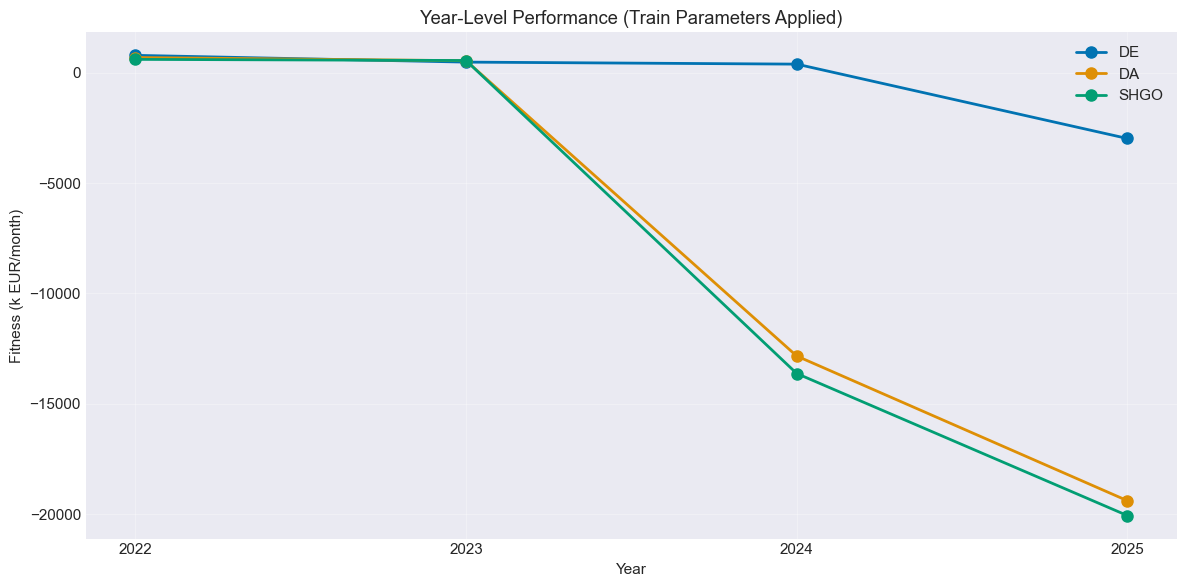

In [24]:
# Plot year-by-year fitness
fig, ax = plt.subplots(figsize=(12, 6))

for algo in ALGORITHMS:
    algo_data = stress_results[stress_results['algorithm'] == algo].sort_values('year')
    ax.plot(algo_data['year'], algo_data['fitness']/1000, 
            marker='o', linewidth=2, markersize=8, label=ALGO_LABELS[algo])

ax.set_xlabel('Year')
ax.set_ylabel('Fitness (k EUR/month)')
ax.set_title('Year-Level Performance (Train Parameters Applied)')
ax.legend()
ax.grid(alpha=0.3)
ax.set_xticks([2022, 2023, 2024, 2025])

plt.tight_layout()
plt.show()

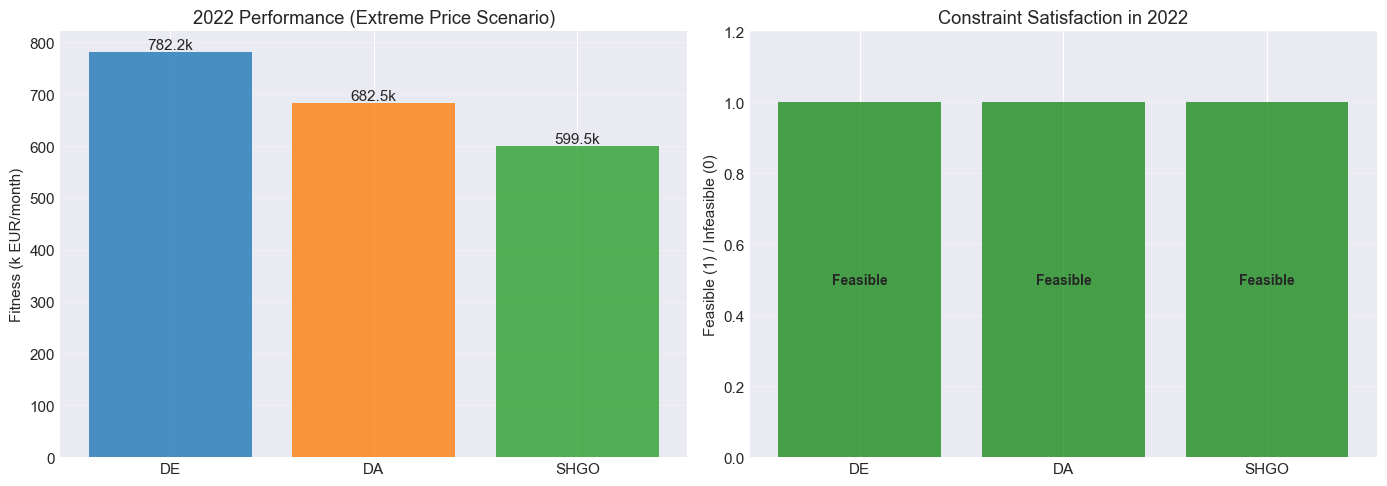

In [25]:
# 2022 focus: Extreme year analysis
stress_2022 = stress_results[stress_results['year'] == 2022].copy()
stress_2022['algo_label'] = stress_2022['algorithm'].map(ALGO_LABELS)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Fitness in 2022
ax = axes[0]
bars = ax.bar(stress_2022['algo_label'], stress_2022['fitness']/1000,
              color=['#1f77b4', '#ff7f0e', '#2ca02c'], alpha=0.8)
ax.set_ylabel('Fitness (k EUR/month)')
ax.set_title('2022 Performance (Extreme Price Scenario)')
ax.grid(axis='y', alpha=0.3)

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.1f}k', ha='center', va='bottom')

# Constraint behaviour in 2022
ax = axes[1]
feasible_2022 = stress_2022['is_feasible'].astype(int)
colors_feasible = ['green' if x else 'red' for x in feasible_2022]
bars = ax.bar(stress_2022['algo_label'], feasible_2022, 
              color=colors_feasible, alpha=0.7)
ax.set_ylabel('Feasible (1) / Infeasible (0)')
ax.set_title('Constraint Satisfaction in 2022')
ax.set_ylim([0, 1.2])
ax.grid(axis='y', alpha=0.3)

for bar, feasible in zip(bars, stress_2022['is_feasible']):
    label = 'Feasible' if feasible else 'Violated'
    ax.text(bar.get_x() + bar.get_width()/2., 0.5,
            label, ha='center', va='center', fontsize=10, weight='bold')

plt.tight_layout()
plt.show()

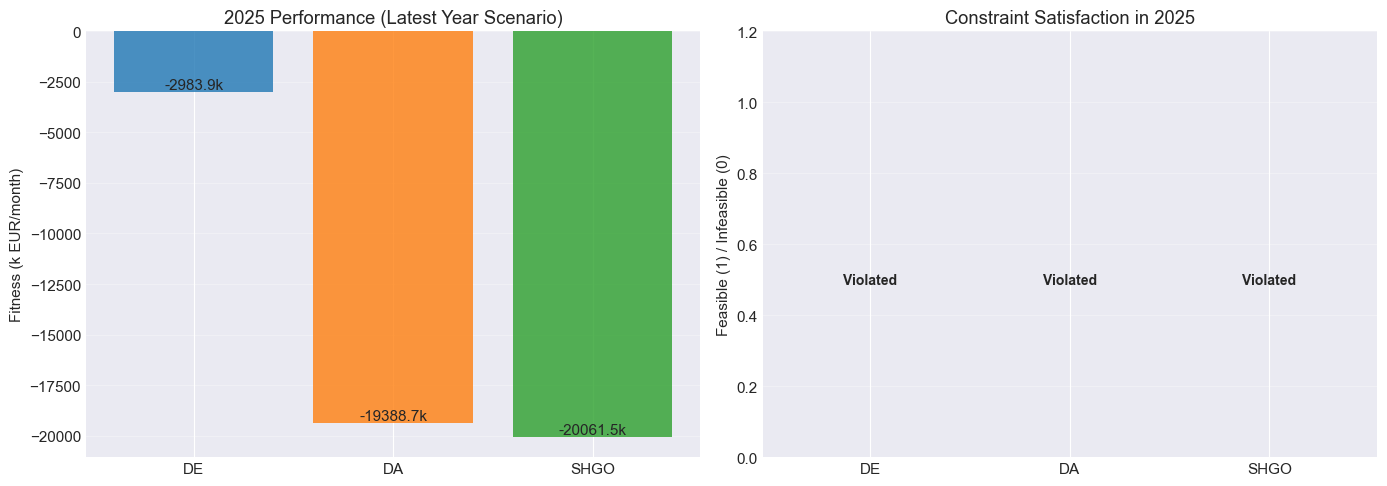

In [26]:
# 2025 focus: Latest year analysis
stress_2025 = stress_results[stress_results['year'] == 2025].copy()
stress_2025['algo_label'] = stress_2025['algorithm'].map(ALGO_LABELS)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Fitness in 2025
ax = axes[0]
bars = ax.bar(stress_2025['algo_label'], stress_2025['fitness']/1000,
              color=['#1f77b4', '#ff7f0e', '#2ca02c'], alpha=0.8)
ax.set_ylabel('Fitness (k EUR/month)')
ax.set_title('2025 Performance (Latest Year Scenario)')
ax.grid(axis='y', alpha=0.3)

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.1f}k', ha='center', va='bottom')

# Constraint behaviour in 2025
ax = axes[1]
feasible_2025 = stress_2025['is_feasible'].astype(int)
colors_feasible = ['green' if x else 'red' for x in feasible_2025]
bars = ax.bar(stress_2025['algo_label'], feasible_2025,
              color=colors_feasible, alpha=0.7)
ax.set_ylabel('Feasible (1) / Infeasible (0)')
ax.set_title('Constraint Satisfaction in 2025')
ax.set_ylim([0, 1.2])
ax.grid(axis='y', alpha=0.3)

for bar, feasible in zip(bars, stress_2025['is_feasible']):
    label = 'Feasible' if feasible else 'Violated'
    ax.text(bar.get_x() + bar.get_width()/2., 0.5,
            label, ha='center', va='center', fontsize=10, weight='bold')

plt.tight_layout()
plt.show()

### 3.4 Annual Performance Trends

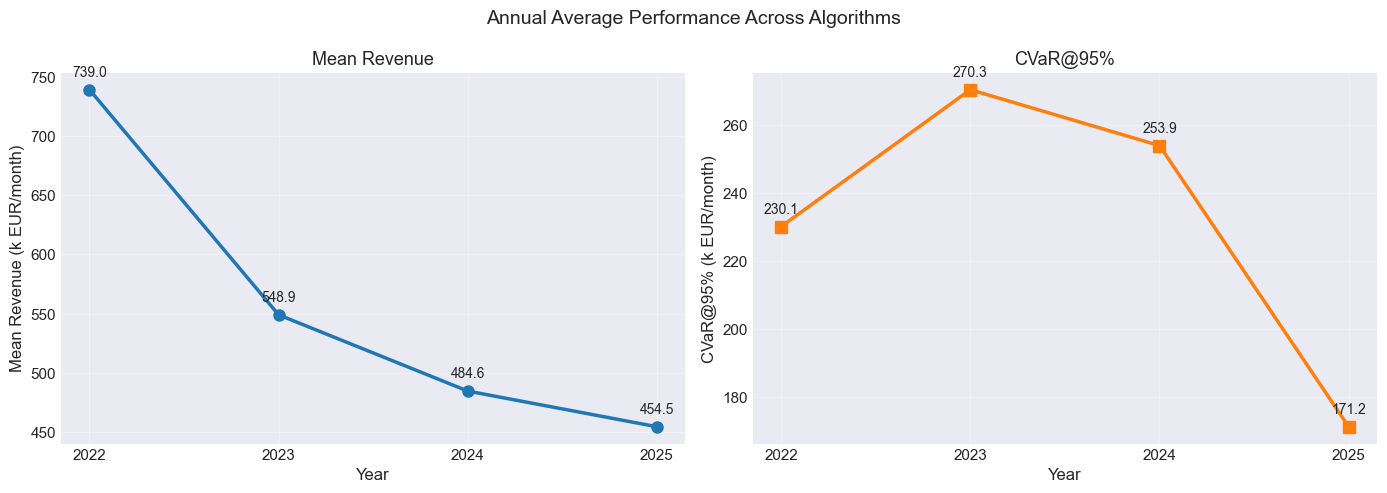


Annual Averages Across Algorithms:
2022: Mean Revenue =  739.0 k EUR/month | CVaR@95% =  230.1 k EUR/month
2023: Mean Revenue =  548.9 k EUR/month | CVaR@95% =  270.3 k EUR/month
2024: Mean Revenue =  484.6 k EUR/month | CVaR@95% =  253.9 k EUR/month
2025: Mean Revenue =  454.5 k EUR/month | CVaR@95% =  171.2 k EUR/month


In [27]:
# Calculate annual averages across all algorithms
years = [2022, 2023, 2024, 2025]
avg_revenue = []
avg_cvar = []

for year in years:
    year_data = stress_results[stress_results['year'] == year]
    avg_revenue.append(year_data['mean_revenue'].mean() / 1000)
    avg_cvar.append(year_data['cvar'].mean() / 1000)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Mean Revenue (left)
ax1 = axes[0]
color1 = '#1f77b4'
ax1.plot(years, avg_revenue, marker='o', linewidth=2.5, markersize=8, 
         color=color1, label='Mean Revenue')
ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Mean Revenue (k EUR/month)', fontsize=12)
ax1.set_xticks(years)
ax1.grid(alpha=0.3)
ax1.set_title('Mean Revenue', fontsize=13)

y1_range = max(avg_revenue) - min(avg_revenue)
for year, val in zip(years, avg_revenue):
    ax1.text(year, val + y1_range * 0.03, f'{val:.1f}', ha='center', va='bottom', 
             fontsize=10)

# CVaR (right)
ax2 = axes[1]
color2 = 'tab:orange'
ax2.plot(years, avg_cvar, marker='s', linewidth=2.5, markersize=8, 
         color=color2, label='CVaR@95%')
ax2.set_xlabel('Year', fontsize=12)
ax2.set_ylabel('CVaR@95% (k EUR/month)', fontsize=12)
ax2.set_xticks(years)
ax2.grid(alpha=0.3)
ax2.set_title('CVaR@95%', fontsize=13)

y2_range = max(avg_cvar) - min(avg_cvar)
for year, val in zip(years, avg_cvar):
    ax2.text(year, val + y2_range * 0.03, f'{val:.1f}', ha='center', va='bottom', 
             fontsize=10)

fig.suptitle('Annual Average Performance Across Algorithms', fontsize=14)

plt.tight_layout()
plt.show()

print("\nAnnual Averages Across Algorithms:")
print("=" * 60)
for year, rev, cv in zip(years, avg_revenue, avg_cvar):
    print(f"{year}: Mean Revenue = {rev:>6.1f} k EUR/month | CVaR@95% = {cv:>6.1f} k EUR/month")

### 3.5 Collar Activation Analysis

In [28]:
# Activation statistics for each algorithm and year
activation_data = []

for algo in ALGORITHMS:
    for year in years:
        # Get optimised parameters for this algorithm
        train_params = results[f'{algo}_train'].iloc[0]
        floor = train_params['floor']
        strike = train_params['strike']
        cap = train_params['cap']
        
        # Filter price data for this year
        year_prices = prices[prices.index.year == year]
        
        # Calculate activations
        total_hours = len(year_prices)
        floor_hours = (year_prices < floor).sum()
        cap_hours = (year_prices >= cap).sum()
        strike_hours = total_hours - floor_hours - cap_hours
        
        activation_data.append({
            'algorithm': ALGO_LABELS[algo],
            'year': year,
            'floor_hours': floor_hours,
            'strike_hours': strike_hours,
            'cap_hours': cap_hours,
            'floor_pct': (floor_hours / total_hours) * 100,
            'strike_pct': (strike_hours / total_hours) * 100,
            'cap_pct': (cap_hours / total_hours) * 100
        })

activation_df = pd.DataFrame(activation_data)
print("Calculated collar activation statistics")

Calculated collar activation statistics


In [29]:
# Create heatmap-style table
print("\nCollar Activation Percentages by Algorithm and Year")
print("=" * 100)

# Pivot data for display
for metric, label in [('floor_pct', 'Floor'), ('strike_pct', 'Strike'), ('cap_pct', 'Cap')]:
    print(f"\n{label} Activation (% of hours):")
    pivot = activation_df.pivot(index='algorithm', columns='year', values=metric)
    
    # Format for display with color indicators
    display = pivot.copy()
    for col in pivot.columns:
        display[col] = pivot[col].apply(lambda x: f"{x:>5.1f}%")
    
    print(display.to_string())

# Summary statistics
print("\n" + "=" * 100)
print("Average Activation Rates Across All Years:")
summary = activation_df.groupby('algorithm')[['floor_pct', 'strike_pct', 'cap_pct']].mean()
summary.columns = ['Floor %', 'Strike %', 'Cap %']
print(summary.round(1).to_string())


Collar Activation Percentages by Algorithm and Year

Floor Activation (% of hours):
year         2022    2023    2024    2025
algorithm                                
DA           3.8%   21.0%   42.9%   42.4%
DE           2.3%   11.0%   26.9%   28.0%
SHGO         3.9%   21.1%   43.1%   42.7%

Strike Activation (% of hours):
year         2022    2023    2024    2025
algorithm                                
DA          71.4%   78.9%   57.1%   57.4%
DE          53.0%   88.4%   72.8%   71.0%
SHGO        85.5%   78.9%   56.9%   57.3%

Cap Activation (% of hours):
year         2022    2023    2024    2025
algorithm                                
DA          24.8%    0.1%    0.0%    0.2%
DE          44.8%    0.6%    0.3%    0.9%
SHGO        10.6%    0.0%    0.0%    0.0%

Average Activation Rates Across All Years:
           Floor %  Strike %  Cap %
algorithm                          
DA            27.6      66.2    6.3
DE            17.1      71.3   11.7
SHGO          27.7      69.6    2.

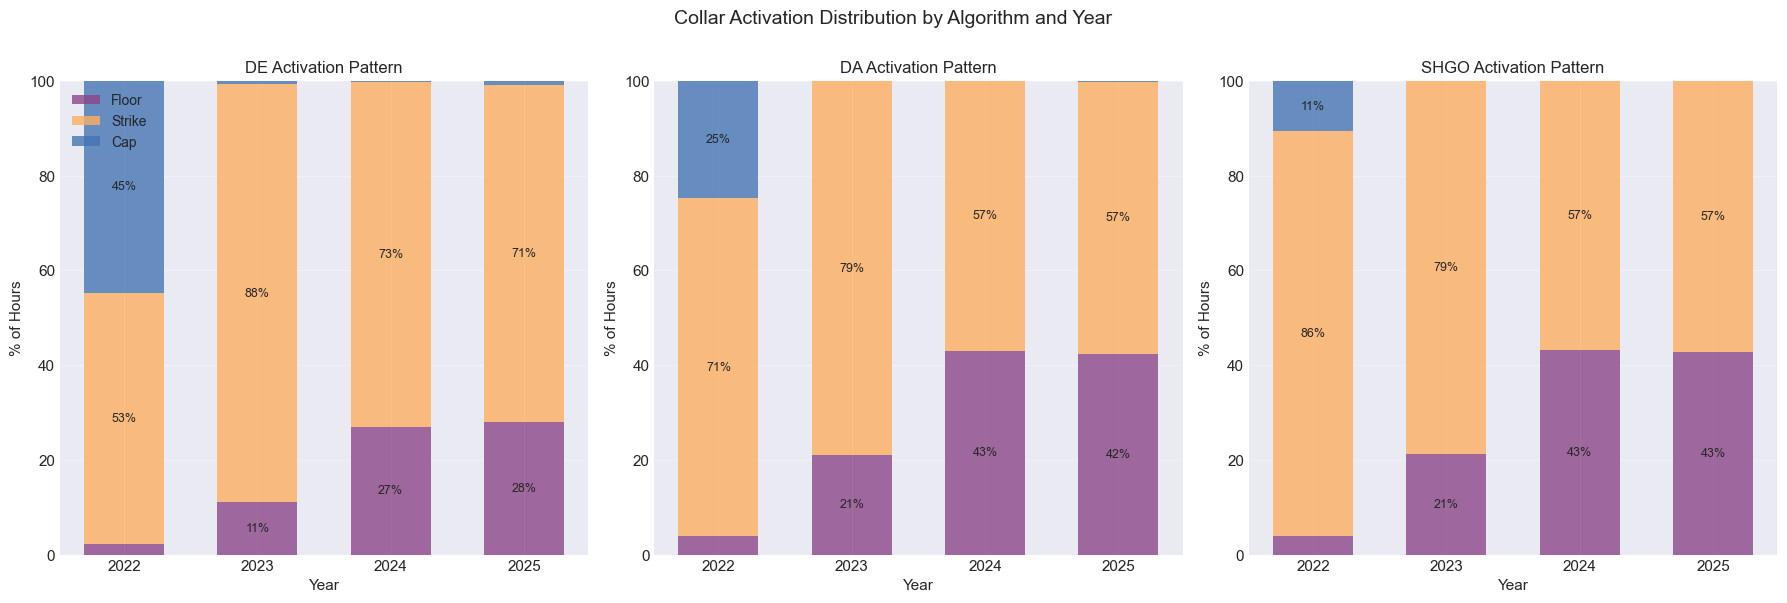

In [30]:
# Activation distribution
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, algo in enumerate(ALGORITHMS):
    ax = axes[idx]
    algo_data = activation_df[activation_df['algorithm'] == ALGO_LABELS[algo]].sort_values('year')
    
    x = np.arange(len(years))
    width = 0.6
    
    # Stacked bars
    floor_bars = ax.bar(x, algo_data['floor_pct'], width, label='Floor', 
                        color='#8B4789', alpha=0.8)
    strike_bars = ax.bar(x, algo_data['strike_pct'], width, 
                         bottom=algo_data['floor_pct'], label='Strike', 
                         color='#FDAE61', alpha=0.8)
    cap_bars = ax.bar(x, algo_data['cap_pct'], width, 
                      bottom=algo_data['floor_pct'] + algo_data['strike_pct'], 
                      label='Cap', color='#4575B4', alpha=0.8)
    
    ax.set_ylabel('% of Hours', fontsize=11)
    ax.set_title(f'{ALGO_LABELS[algo]} Activation Pattern', fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels(years)
    ax.set_xlabel('Year', fontsize=11)
    ax.set_ylim([0, 100])
    ax.grid(axis='y', alpha=0.3)
    
    # Add percentage labels
    for i, year_idx in enumerate(x):
        floor_val = algo_data.iloc[i]['floor_pct']
        strike_val = algo_data.iloc[i]['strike_pct']
        cap_val = algo_data.iloc[i]['cap_pct']
        
        # Label if segment is large enough
        if floor_val > 5:
            ax.text(year_idx, floor_val/2, f'{floor_val:.0f}%', 
                   ha='center', va='center', fontsize=9)
        if strike_val > 5:
            ax.text(year_idx, floor_val + strike_val/2, f'{strike_val:.0f}%', 
                   ha='center', va='center', fontsize=9)
        if cap_val > 5:
            ax.text(year_idx, floor_val + strike_val + cap_val/2, f'{cap_val:.0f}%', 
                   ha='center', va='center', fontsize=9)
    
    if idx == 0:
        ax.legend(loc='upper left', fontsize=10)

fig.suptitle('Collar Activation Distribution by Algorithm and Year', fontsize=14, y=1.00)
plt.tight_layout()
plt.show()